# Demo file: ML based signal generation

### Imports

In [ ]:
# uv pip install joblib
# uv pip install scipy
# uv pip install scikit-learn
# uv pip install shap
# uv pip install tqdm

In [36]:
# Standard library imports
import os
import sys
from pathlib import Path
import subprocess

# Third party imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from scipy.stats import spearmanr
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import make_scorer
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, KFold
from sklearn.base import clone
import shap

# Local imports
# Add the project root directory to Python path
project_root = os.path.dirname(os.path.dirname(os.getcwd()))   # Change this path if needed
src_path = os.path.join(project_root, 'src')
sys.path.append(project_root)
sys.path.append(src_path)
from helper_functions import load_data_spi, align_market_data_with_jkp_data
from ml.utils.format import check_if_multiindex, ensure_datetime_index
from ml.utils.grid import compound_returns_on_grid, shift_grid_returns
from ml.utils.format import check_if_multiindex, ensure_datetime_index
from ml.transformers.pipeline import TransformPipeline
from ml.transformers.panel.cross_sectional import (
    CrossSectionalWinsorize,
    CrossSectionalZScore,
    CrossSectionalClip,
    CrossSectionalPIT,
)
from ml.metrics.scoring import ic_score_func, spearman_correlation_per_date, mae_per_date
from ml.splitters.rolling_timeseries_split import PanelTimeSeriesSplit
from ml.splitters.rolling_timeseries_split import ObservationGridRollingSplit
from ml.training.traintest import train_func, test_func
from ml.explain.xai import get_shaply_values

### Control params

In [8]:
label_recompute = False
feature_recompute = False
start_date = "2000-01-01"
end_date = "2023-01-01"

### Data paths

In [14]:

data_path = Path('C:/Users/User/OneDrive/Documents/QPMwP/Data')  # Change this path if needed

# return series
return_series_path = data_path / "return_series.parquet"

# generated input to training
feature_path = str(data_path / "features.parquet")
label_path = str(data_path / "labels.parquet")

# generated predictions
prediction_path = str(data_path / "ml_signal.parquet")
shap_path = str(data_path / "shap_values.parquet")

### Load data

In [15]:
# Load market and jkp data from parquet files
market_data = pd.read_parquet(path = data_path / "market_data.parquet")
jkp_data = pd.read_parquet(path = data_path / "jkp_data.parquet")

# Align market data with jkp data and forward fill missing values in market data
market_data_ffill, jkp_data = align_market_data_with_jkp_data(market_data=market_data, jkp_data=jkp_data)
market_data_ffill.index.names = ["DATE", "ID"]
jkp_data.index.names = ["DATE", "ID"]

# Calc daily returns and save as parquet file
X = market_data_ffill.pivot_table(index="DATE", columns="ID", values="price")
end_date = X.index.max().strftime("%Y-%m-%d")
width = X.shape[0] - 1
daily_ret = X[X.index <= end_date].tail(width + 1).pct_change(fill_method=None).iloc[1:]
daily_ret = daily_ret.stack()
daily_ret.index.names = ["DATE", "ID"]
daily_ret.name = "tot_return_gross"
daily_ret.dropna().to_frame().to_parquet(data_path / "return_series.parquet")

### Features

In [16]:
# only True for testing purposes to make the code fast
downsample = False

if Path(feature_path).exists() and not feature_recompute:

    print(f"Loading features from {feature_path}")
    X = pd.read_parquet(feature_path)

else:

    print(f"Preparing features from raw data in {data_path}")

    feature_cols = [
        "ret_6_1",      # Momentum6
        "ret_12_1",     # Momentum12  
        "qmj",          # Quality minus Junk
        "qmj_growth",   # GrowthComp
        "qmj_safety",   # SafetyComp
        "gp_at",        # GrossProfit
        "op_at",        # OpProfit
        "be_me",        # BookValue
        "debt_me",      # Leverage
        "at_gr1",       # AssetGrowth
        "oaccruals_at", # Accruals
    ]

    # load signals
    X = pd.read_parquet(path=data_path / "jkp_data.parquet")
    X = X[feature_cols]

    X.index.names = ["DATE", "ID"]

    # keep only numeric columns (for now)
    X = X.select_dtypes(include="number")

    # Todo: one hot encode string features...

    # forward fill, 1y max
    X = X.groupby(level="ID").ffill(limit=4)

    # only for the example, in practice more careful
    X = X.dropna()

    # find first DATE with more than 50 unique IDs and no NAs
    dates_id_counts = X.dropna().groupby(level="DATE").size()
    start_date_id = dates_id_counts[dates_id_counts > 50].index[0]
    print(f"Start date (first DATE with >50 IDs): {start_date_id}")

    X = X.loc[X.index.get_level_values("DATE") >= start_date_id]

    # remove duplicates
    X = X[~X.index.duplicated(keep="last")]

    # check if we have the proper panel format
    check_if_multiindex(X)

    # check if date level is datetime, if not convert
    X = ensure_datetime_index(X)

    # sort
    X = X.sort_index()

    # assess the sample size over time
    # X.groupby(level="DATE").count().plot(title="Number of IDs per DATE")

    ################################
    # DownSampling
    ################################

    if downsample:
        # Find IDs present on EVERY date
        id_counts = X.index.get_level_values("ID").value_counts()

        time_grid = X.index.get_level_values("DATE").unique().sort_values()

        # First 10
        consistent_ids = id_counts[id_counts == len(time_grid)].index[:10]

        # Filter to only those IDs
        id_mask = X.index.get_level_values("ID").isin(consistent_ids)
        X = X[id_mask]

print(f"Features prepared: X.shape={getattr(X, 'shape', None)}")

Loading features from C:\Users\User\OneDrive\Documents\QPMwP\Data\features.parquet
Features prepared: X.shape=(34557, 11)


### Label creation

In [17]:
# time grid for label creation
time_grid = X.index.get_level_values("DATE").unique().sort_values()

# if label file exists, load it otherwise compute and persist
if Path(label_path).exists() and not label_recompute:

    print(f"Loading labels from {label_path}")

    # load the label
    y_df = pd.read_parquet(label_path)

    # downstream needs a series
    y = y_df.squeeze()

else:

    print(f"Preparing labels from raw data in {data_path}")
    # on s3 we still have multi columns

    return_series = pd.read_parquet(return_series_path, columns=["tot_return_gross"])
    # return_series = pd.read_parquet(return_series_path)

    # check if we have the proper panel format
    check_if_multiindex(return_series)

    # check if date level is datetime, if not convert
    return_series = ensure_datetime_index(return_series)

    # daily returns
    daily_ret = return_series.sort_index()

    # grid returns
    grid_ret = compound_returns_on_grid(
        return_series=daily_ret.squeeze(),
        time_grid=time_grid,
    )

    # shift back one unit on the grid
    y = shift_grid_returns(grid_ret, shift=-1)

    # remove duplicates
    y = y[~y.index.duplicated(keep="last")]

    
    # label transformation pipeline
    label_pipeline = TransformPipeline(
        [
            # CrossSectionalZScore(),
            CrossSectionalWinsorize(lower=0.01, upper=0.99),
            CrossSectionalPIT(),
        ]
    )

    y = label_pipeline.fit_transform(y)
    y = y.dropna()

print(f"Labels prepared: y.shape={getattr(y, 'shape', None)}")

Loading labels from C:\Users\User\OneDrive\Documents\QPMwP\Data\labels.parquet
Labels prepared: y.shape=(34557,)


### Alignment of X and y

In [18]:
common_index = X.index.intersection(y.index).sort_values()
X = X.loc[common_index]
y = y.loc[common_index]

print(f"Aligned X and y: X.shape={X.shape}, y.shape={y.shape}")
assert X.index.equals(y.index)


# persist the aligned
if not Path(feature_path).exists() or feature_recompute:
    print("Persisting Features")
    X.to_parquet(feature_path)

# persist the label for future use
if not Path(label_path).exists() or label_recompute:
    print("Persisting Labels")
    y.to_frame("return").to_parquet(label_path)


print(f"Aligned X and y: X.shape={X.shape}, y.shape={y.shape}")

Aligned X and y: X.shape=(34557, 11), y.shape=(34557,)
Aligned X and y: X.shape=(34557, 11), y.shape=(34557,)


### Define a model / pipeline

In [19]:
ic_score = make_scorer(ic_score_func, greater_is_better=True)

# linear model
pipeline = Pipeline(
    [
        # not really needed since our input is very tamed
        #("scaler", MinMaxScaler()),
        # add squared features
        #("poly", PolynomialFeatures(degree=2, include_bias=False)),
        # simple regressor
        #("pca", PCA()),
        ("regressor", Ridge(random_state=42))
    ]
)

param_grid = {"regressor__alpha": [1e-6, 1e-2, 0.1, 1.0, 10.0, 100.0, 1e6]}
explainer_type = "linear"


# # Neural Net (better to use pytorch if you want transformers etc.)
# # skorch is a good wrapper to keep the below framework
# from sklearn.neural_network import MLPRegressor

# pipeline = Pipeline(
#     [
#         # MLP is sensitive to feature scale
#         ("scaler", StandardScaler()),
#         (
#             "regressor",
#             MLPRegressor(
#                 hidden_layer_sizes=(64, 32),
#                 activation="relu",
#                 solver="adam",
#                 max_iter=200,
#                 early_stopping=True,
#                 validation_fraction=0.1,
#                 random_state=42,
#             ),
#         ),
#     ]
# )

# param_grid = {
#     "regressor__hidden_layer_sizes": [(64, 32), (128, 64), (64, 32, 16)],
#     "regressor__alpha": [1e-4, 1e-3, 1e-2],  # L2 regularization
#     "regressor__learning_rate_init": [1e-3, 5e-4],
# }

# XGBoost model
# from xgboost import XGBRegressor
# pipeline = Pipeline(
#     [
#         (
#             "regressor",
#             XGBRegressor(
#                 objective="reg:absoluteerror",
#                 random_state=42,)
#                 n_estimators=200,
#                 tree_method="hist",
#             ),
#         ),
#     ]
# )
# param_grid = {
#     "regressor__max_depth": [2, 3],
#     "regressor__learning_rate": [0.01, 0.02],
#     "regressor__n_estimators": [10, 50],
#     "regressor__reg_alpha": [0.5, 1.0, 2.0],      # L1 regularization
#     "regressor__reg_lambda": [1.0, 5.0, 10.0],    # L2 regularization
#     "regressor__min_child_weight": [5, 10],       # Prevent small leaves
#     "regressor__subsample": [0.6, 0.8],           # Row subsampling
#     "regressor__colsample_bytree": [0.6, 0.8],   # Column subsampling
# }
# explainer_type = "tree"


# # more complex pipeline
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import RobustScaler
# from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression
# from sklearn.decomposition import PCA

# pipeline = Pipeline(
#     [
#         # guard against unseen nans at inference; median robust to outliers
#         ("imputer", SimpleImputer(strategy="median")),
#         # drop near-constant features before scaling
#         ("variance_filter", VarianceThreshold(threshold=1e-4)),
#         # iqr-based scaling; fat-tailed signals (momentum etc.) break std-based scalers
#         ("scaler", RobustScaler(quantile_range=(5.0, 95.0))),
#         # univariate linear filter; k swept in grid so the filter can be disabled
#         ("feature_selection", SelectKBest(score_func=f_regression, k=8)),
#         # decorrelates redundant features, n_components=None = passthrough
#         ("pca", PCA(n_components=None, whiten=True)),
#         (
#             "regressor",
#             XGBRegressor(
#                 objective="reg:absoluteerror",
#                 tree_method="hist",
#                 random_state=42,
#                 n_estimators=500,
#                 subsample=0.8,
#                 colsample_bytree=0.8,
#                 reg_alpha=0.1,       # l1: sparsifies feature usage across trees
#                 reg_lambda=5.0,      # l2: shrinks leaf weights, both can coexist
#                 min_child_weight=5,
#                 gamma=0.1,
#             ),
#         ),
#     ]
# )

# param_grid = {
#     # data-prep
#     "imputer__strategy": ["median", "mean"],
#     "feature_selection__k": [6, 8, "all"], # "all" disables the filter
#     "pca__n_components": [None, 5],          # None = pca off

#     # tree structure
#     "regressor__max_depth": [3, 4, 5],
#     "regressor__learning_rate": [0.01, 0.03, 0.05],

#     # stochastic subsampling
#     "regressor__subsample": [0.7, 0.85, 1.0],
#     "regressor__colsample_bytree": [0.7, 0.85, 1.0],

#     # regularisation — l1 and l2 are independent and swept jointly
#     "regressor__reg_alpha": [0.0, 0.1, 1.0],
#     "regressor__reg_lambda": [1.0, 5.0, 10.0],
#     "regressor__min_child_weight": [3, 5, 10],
#     "regressor__gamma": [0.0, 0.1, 0.5],
# }

# Todo: implement XGBRanker if you want to do direct ranking optimization, 
# from xgboost import XGBRanker
# pipeline = Pipeline(
#     [("regressor", XGBRanker(objective='rank:ndcg'))]
# )


### Grid Search

In [20]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    # cv=KFold(n_splits=5),
    cv=PanelTimeSeriesSplit(n_splits=4, date_level="DATE"),
    n_jobs=-1,
    scoring=ic_score,
    # scoring="neg_mean_squared_error",
    refit=True,
)

### Time Grid for Rolling Split

In [21]:
# this can only be done if X and y are aligned
time_grid = X.index.get_level_values("DATE").unique().sort_values()

# to reduce the sample size for testing purposes,
# we can filter the time grid to start from a later date
# also the compustat data seem poor in the very last years
if start_date is not None:
    time_grid = time_grid[time_grid > start_date]
if end_date is not None:
    time_grid = time_grid[time_grid < end_date]

### Train and Test Rolling Split

In [22]:
rolling_splitter = ObservationGridRollingSplit(
    observation_dates=time_grid,
    train_window_obs=12,
    skip_obs_between_train_test=0,
    retrain_stride=1,
)

rolling_splitter.print_splits(X=X)


============ [iteration 01] ============
training_period
start <-> end: 2000-01-31 <-> 2000-12-31
number of samples: 702
number of unique dates: 12
dates: ['2000-01-31', '2000-02-29', '2000-03-31', '2000-04-30', '2000-05-31', '2000-06-30', '2000-07-31', '2000-08-31', '2000-09-30', '2000-10-31', '2000-11-30', '2000-12-31']
testing_period
start <-> end: 2001-01-31 <-> 2001-01-31
number of samples: 61
number of unique dates: 1
dates: ['2001-01-31']

============ [iteration 02] ============
training_period
start <-> end: 2000-02-29 <-> 2001-01-31
number of samples: 708
number of unique dates: 12
dates: ['2000-02-29', '2000-03-31', '2000-04-30', '2000-05-31', '2000-06-30', '2000-07-31', '2000-08-31', '2000-09-30', '2000-10-31', '2000-11-30', '2000-12-31', '2001-01-31']
testing_period
start <-> end: 2001-02-28 <-> 2001-02-28
number of samples: 61
number of unique dates: 1
dates: ['2001-02-28']

============ [iteration 03] ============
training_period
start <-> end: 2000-03-31 <-> 2001-02-28

### Train (will persist the models to disk)

In [25]:
n_jobs = joblib.effective_n_jobs()

# if already trained will not do it again
# run the training of the models in parallel, this will take time
with joblib.parallel_backend("loky", n_jobs=n_jobs, verbose=True):
    jobs = []
    jobs.extend(
        joblib.delayed(train_func)(
            # train_func(
            model=clone(grid_search),
            X=X,
            y=y,
            train_idx=train_idx,
            # if you want a model by asset, pass y as a wide dataframe and
            # loop over assets here with target_asset=asset_name
            # target_asset=target_asset,
            force_retrain=True,  # set to False to skip retraining if model already exists
        )
        for train_idx, _ in rolling_splitter.split(X=X)
    )

    joblib.Parallel()(jobs)


print("Training Done")

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 out of 278 | elapsed:    9.4s
[Parallel(n_jobs=8)]: Done 184 out of 278 | elapsed:   23.0s


Training Done


[Parallel(n_jobs=8)]: Done 278 out of 278 | elapsed:   31.9s finished


### Test (will load the models from disk and generate predictions)

In [26]:
n_jobs = joblib.effective_n_jobs()
# n_jobs = 50

# run the test, which is simply generating the predictions
# here also in parallel
with joblib.parallel_backend("loky", n_jobs=n_jobs, verbose=True):
    jobs = []
    jobs.extend(
        joblib.delayed(test_func)(
            X=X,
            y=y,
            train_idx=train_idx,
            test_idx=test_idx,
        )
        for train_idx, test_idx in rolling_splitter.split(X=X)
    )

    # list of tuples (resolved_target, y_pred_test, y_pred_train)
    result = joblib.Parallel()(jobs)

print("Testing Done")

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  56 out of 278 | elapsed:    0.3s


Testing Done


[Parallel(n_jobs=8)]: Done 278 out of 278 | elapsed:    1.0s finished


### Persist the predictions

In [28]:
# build dataframe from y_pred_test (second element of tuple)
# then unstack to have a dataframe with index DATE and columns ID, values are predictions
y_pred_test_df = pd.concat(
    [item[1] for item in result],
    axis=0,
).unstack()

print(f"Predictions head:\n{y_pred_test_df.head()}")
print(f"Predictions index:\n{y_pred_test_df.index}")

row_non_na_counts = y_pred_test_df.count(axis=1)
print(f"# of predictions per unique DATE: {row_non_na_counts}")

y_pred_test_df.to_parquet(prediction_path)

print(f"Stored Predictions in {prediction_path}")
print("Predictions Done")

Predictions head:
              y_pred                                                    \
ID               101       102       103       104       105       107   
DATE                                                                     
2001-01-31  0.471680  0.492745  0.566506  0.496237  0.527916  0.475457   
2001-02-28  0.477133  0.492541  0.570830  0.505880  0.552290  0.469566   
2001-03-31  0.468720  0.495222  0.585723  0.509589  0.558579  0.464187   
2001-04-30  0.510349  0.510325  0.510366  0.510301  0.510361  0.510308   
2001-05-31  0.509845  0.480853  0.547688  0.474980  0.558900  0.450762   

                                                    ...                      \
ID               111       113       118       119  ... 299  38 297 302 303   
DATE                                                ...                       
2001-01-31  0.482899  0.468186  0.512019  0.492979  ... NaN NaN NaN NaN NaN   
2001-02-28  0.498587  0.475004  0.499264  0.503725  ... NaN NaN NaN NaN N

### Shap values computation

In [40]:
n_jobs = joblib.effective_n_jobs()
# n_jobs = 50

# run the test, which is simply generating the predictions
# here also in parallel
with joblib.parallel_backend("loky", n_jobs=n_jobs, verbose=True):
    jobs = []
    jobs.extend(
        joblib.delayed(get_shaply_values)(
            X=X,
            y=y,
            train_idx=train_idx,
            target_asset=None,
            explainer_type=explainer_type,
        )
        for train_idx, _ in rolling_splitter.split(X=X)
    )

    # list of tuples (resolved_target, y_pred_test, y_pred_train)
    result = joblib.Parallel()(jobs)

# collect results and persist in redable form
dfs = []

for i, sv in enumerate(result):
    df = pd.DataFrame(
        sv.values,
        columns=sv.feature_names,
        # index=X.index # poor solution, pipeline might have dropped rows
    )
    df["split"] = i
    dfs.append(df)

df_all_shap = pd.concat(dfs)
df_all_shap.to_parquet(shap_path)


print(f"Saved SHAP values to {shap_path}")

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 out of 278 | elapsed:    4.8s
[Parallel(n_jobs=8)]: Done 278 out of 278 | elapsed:    7.2s finished


Saved SHAP values to C:\Users\User\OneDrive\Documents\QPMwP\Data\shap_values.parquet


### Shap value analysis

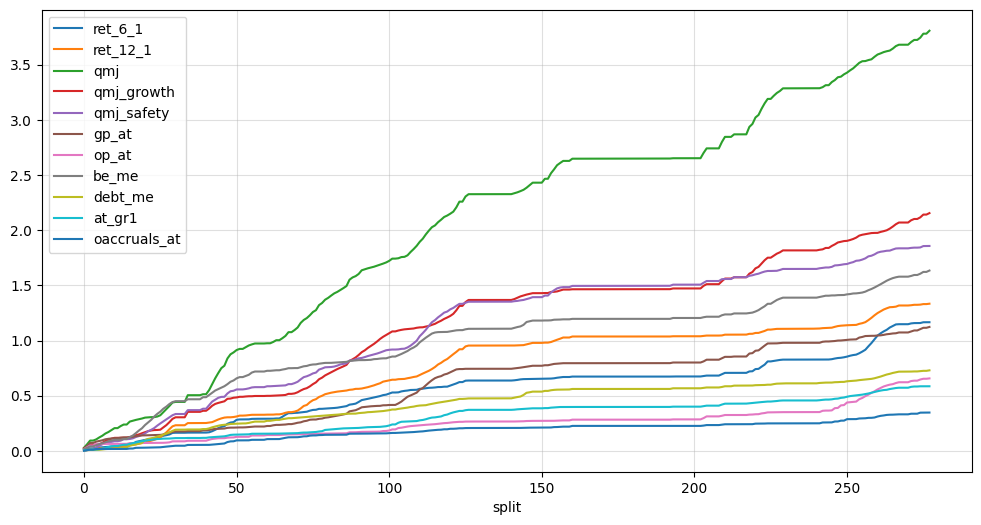

qmj             0.013694
qmj_growth      0.007749
qmj_safety      0.006678
be_me           0.005877
ret_12_1        0.004796
ret_6_1         0.004193
gp_at           0.004039
debt_me         0.002625
op_at           0.002362
at_gr1          0.002105
oaccruals_at    0.001249
dtype: float64

In [41]:
# java script based visualizations, only works in jupyter.
shap.initjs()

# load all shap values
df_all_shap = pd.read_parquet(shap_path)

importance = df_all_shap.drop(columns="split").abs().groupby(df_all_shap["split"]).mean()

# feature importance plot through time / the splits currently
importance.cumsum().plot(figsize=(12, 6))
plt.grid(alpha=0.4)
plt.show()

importance.mean().sort_values(ascending=False)

### Metric analysis on test predictions

C:\Users\User\AppData\Local\Temp\ipykernel_15860\3069193945.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  y_hat = pd.read_parquet(prediction_path).stack().dropna()


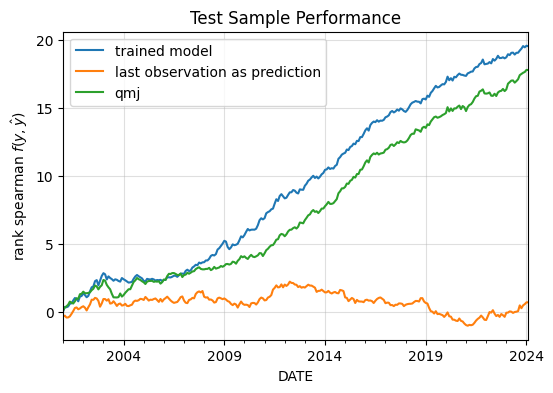

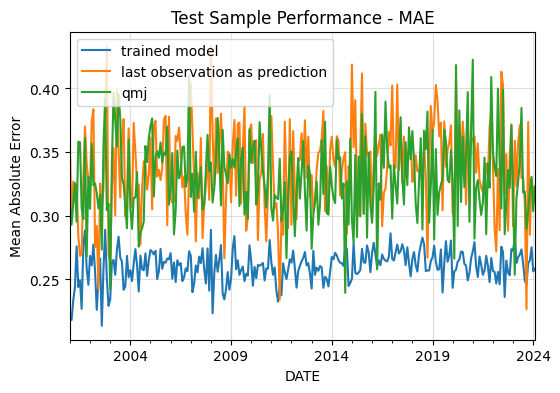

In [42]:
y_hat = pd.read_parquet(prediction_path).stack().dropna()
y = pd.read_parquet(label_path).squeeze()
X = pd.read_parquet(feature_path)


# Compute metrics and store in a dataframe
metrics_df = pd.DataFrame({
    "trained_model": spearman_correlation_per_date(y_true=y, y_pred=y_hat),
    "last_observation": spearman_correlation_per_date(y_true=y, y_pred=y.groupby(level="ID").shift(1).dropna()),
    "qmj": spearman_correlation_per_date(y_true=y, y_pred=X['qmj']),
})

# Plot cumulative sum
metrics_df.dropna().cumsum().plot(figsize=(6, 4))
plt.title("Test Sample Performance")
plt.ylabel(r"rank spearman $f(y,\hat{y})$")
plt.legend(["trained model", "last observation as prediction", "qmj"], loc="upper left")
plt.grid(alpha=0.4)
plt.show()

# Compute MAE metrics
y_sf = X['qmj']

# Scale qmj feature by date
y_sf_date_scaled = y_sf.groupby(level="DATE").transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

metrics_df2 = pd.DataFrame({
    "trained_model": mae_per_date(y_true=y, y_pred=y_hat),
    "last_observation": mae_per_date(y_true=y, y_pred=y.groupby(level="ID").shift(1).dropna()),
    "qmj": mae_per_date(y_true=y, y_pred=y_sf_date_scaled),
})

# Plot MAE
metrics_df2.dropna().plot(figsize=(6, 4))
plt.title("Test Sample Performance - MAE")
plt.ylabel("Mean Absolute Error")
plt.legend(["trained model", "last observation as prediction", "qmj"], loc="upper left")
plt.grid(alpha=0.4)
plt.show()

### Train and test error

In [43]:
# train and test evaluation
ic_train = []
ic_test = []
for item in result:
    _, y_hat_test, y_hat_train = item

    ic_test.append(ic_score_func(y.reindex(y_hat_test.index), y_hat_test.values.reshape(-1)))
    ic_train.append(ic_score_func(y.reindex(y_hat_train.index), y_hat_train.values.reshape(-1)))


plt.plot((np.array(ic_test)), label="IC Test")
plt.plot((np.array(ic_train)), label="IC Train")
plt.legend()
plt.grid(alpha=0.4)
plt.show()

y.reindex(y_hat.index), y_hat
ic_score_func(y.reindex(y_hat.index), y_hat.values.reshape(-1))
pd.Series(y_hat.values.reshape(-1))

ValueError: too many values to unpack (expected 3)

### Look at one example / split

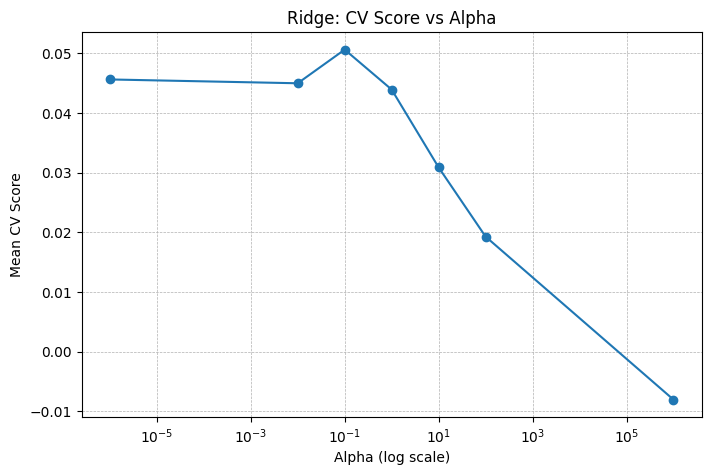

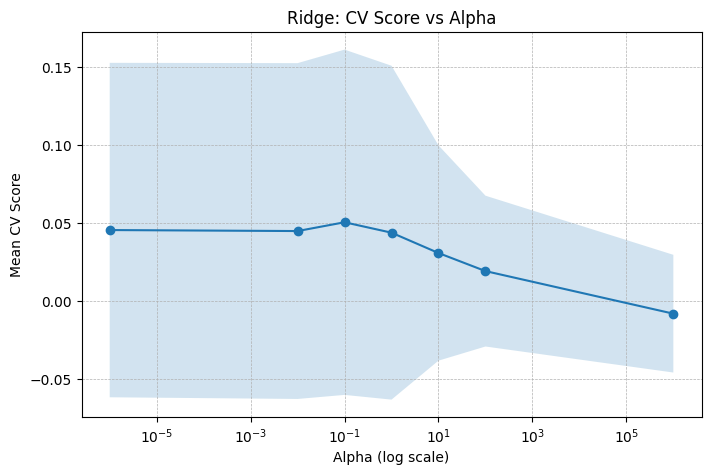

oaccruals_at   -0.093572
gp_at          -0.073358
ret_6_1        -0.044402
qmj_growth     -0.020963
at_gr1         -0.015797
ret_12_1       -0.006414
debt_me        -0.002590
qmj_safety      0.007126
be_me           0.021039
qmj             0.035522
op_at           0.351727
dtype: float64


In [39]:
splits = rolling_splitter.split(X=X)

# get training info of first split
# first split
train_idx, test_idx = next(splits)
# this is how you move to the next split
train_idx, test_idx = next(splits)

X_train = X.loc[train_idx]
y_train = y.loc[train_idx]

# clone model and fit
model = clone(grid_search)
model.fit(X=X_train, y=y_train)

# results from GridSearchCV
results = model.cv_results_

# Find all hyperparameter columns
param_cols = [c for c in results.keys() if c.startswith("param_regressor__")]

# extract values for each parameter
param_data = {}
for c in param_cols:
    values = np.array(results[c])
    try:
        values = values.astype(float)
    except:
        pass
    param_data[c.replace("param_regressor__", "")] = values

# add the test score (negative mse, higher is better)
param_data["mean_test_score"] = results["mean_test_score"]
param_data["std_test_score"] = results["std_test_score"]
# ad the mse (sign flip, note this will need chagnes if you change the score func.)
param_data["mean_test_mse"] = -results["mean_test_score"]

# Make DataFrame
df = pd.DataFrame(param_data)

# sorting
param_name = "alpha"  # or alpha or what is suitable
df = df.sort_values(by=[param_name], ascending=False)
# df = df.sort_values(by=["alpha"], ascending=False)

# simple Hyperparam plot for Ridge Regression
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.semilogx(df[param_name], df["mean_test_score"], marker="o", linestyle="-")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Mean CV Score")
plt.title("Ridge: CV Score vs Alpha")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

# why is the standard deviation so high?
plt.figure(figsize=(8, 5))

# Semilog-x plot with shaded std region
plt.semilogx(
    df[param_name], df["mean_test_score"], marker="o", linestyle="-", label="Mean CV MSE"
)
plt.fill_between(
    df[param_name],
    df["mean_test_score"] - df["std_test_score"],
    df["mean_test_score"] + df["std_test_score"],
    alpha=0.2,
)

plt.xlabel("Alpha (log scale)")
plt.ylabel("Mean CV Score")
plt.title("Ridge: CV Score vs Alpha")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

print(
    pd.Series(
        model.best_estimator_.named_steps["regressor"].coef_, index=X.columns
    ).sort_values()
)
